# Data Preparation \& Exploratory Data Analysis

This notebook documents the complete data pipeline from raw scraping outputs
to the analysis-ready dataset used for modelling. Each section shows the
transformations applied, intermediate artifacts, and data-quality discoveries
that informed downstream decisions.


In [1]:
import io, os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".")
sys.path.insert(0, str(ROOT))

from src.viz.style import (
    apply_style, latex_safe, add_bar_labels,
    PALETTE, COLOR_PRIMARY, COLOR_ACCENT, COLOR_GOOD, COLOR_BAD,
    TABLE_HEADER, TABLE_ROW_ALT,
    FIGSIZE_SINGLE, FIGSIZE_WIDE, FIGSIZE_TALL, FIGSIZE_TABLE,
)
apply_style()

DATA_RAW = ROOT / "data" / "raw"
DATA_INTERIM = ROOT / "data" / "interim"
REPORTS = ROOT / "reports" / "prep_eda"
REPORTS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(f"Project root: {ROOT}")
print(f"Reports dir:  {REPORTS}")


Project root: C:\Users\dduya\Work\project\ev_car
Reports dir:  C:\Users\dduya\Work\project\ev_car\reports\prep_eda


## 1. Raw Data Sources

Four Vietnamese car marketplace websites were scraped to build the EV dataset.
Each source has a different schema, format, and level of detail.

| Source | Format | Description |
|--------|--------|-------------|
| bonbanh.com | CSV | General car marketplace, pre-scraped |
| chotot.com | JSON | Classified ads platform (Scrapy) |
| otodien.vn | CSV | EV-only platform with detailed specs |
| xevinfastluot.com | CSV | VinFast specialist dealer |


In [2]:
# --- 1a. bonbanh.com ---
bb_path = DATA_RAW / "bonbanh.csv"
try:
    df_bb = pd.read_csv(bb_path, encoding="utf-8-sig")
    print(f"bonbanh.com: {df_bb.shape[0]:,} records x {df_bb.shape[1]} columns")
    print(f"Columns: {list(df_bb.columns)}")
    display(df_bb.head(2))
except Exception as e:
    df_bb = pd.DataFrame()
    print(f"Failed to load bonbanh.csv: {e}")


bonbanh.com: 1,493 records x 19 columns
Columns: ['Ngày đăng', 'Tên xe', 'Giá', 'Tên người bán', 'Địa chỉ', 'Năm sản xuất', 'Tình trạng', 'Số Km đã đi', 'Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Động cơ', 'Màu ngoại thất', 'Màu nội thất', 'Số chỗ ngồi', 'Số cửa', 'Dẫn động', 'Mô tả', 'Link']


,Ngày đăng,Tên xe,Giá,Tên người bán,Địa chỉ,Năm sản xuất,Tình trạng,Số Km đã đi,Xuất xứ,Kiểu dáng,Hộp số,Động cơ,Màu ngoại thất,Màu nội thất,Số chỗ ngồi,Số cửa,Dẫn động,Mô tả,Link
0,28/02/2026,Xe\r\n\r\n\t\t\t\t\t\t\tVinFast VF8\r\n\t\t\t\t\t\tPlus AWD\r\n\t\t\t\t\t\t2023,659 Triệu,GF Hoàng Quốc Việt,"14 Hoàng Quốc Việt, Cầu Giấy Hà Nội",2023,Xe đã dùng,"50,000 Km",Lắp ráp trong nước,SUV,Số tự động,Điện,Đen,Đen,5 chỗ,5 cửa,AWD - 4 bánh toàn thời gian,VF8 2022 MÀU ĐEN – XE ĐẸP BẢN PLUS – QUÀ NOEL HẤP DẪN! | Cuối năm săn xe đẹp...,https://bonbanh.com/xe-vinfast-vf8-plus-awd-2023-6592486
1,28/02/2026,Xe\r\n\r\n\t\t\t\t\t\t\tVinFast VF8\r\n\t\t\t\t\t\tEco\r\n\t\t\t\t\t\t2026,790 Triệu,Vinfast Times City,"Tầng B1, TTTM Vincom Times City - 458 Minh Khai, Vĩnh Tuy, Hai Bà Trưng Hà Nội",2026,Xe mới,NaN,Lắp ráp trong nước,SUV,Số tự động,Điện,Trắng,Đen,5 chỗ,5 cửa,FWD - Dẫn động cầu trước,Vinfast VF8 (VF E35) 2026 | Xe điện mới 100% | Kích thước tổng thể (DxRxC) (...,https://bonbanh.com/xe-vinfast-vf8-eco-2026-6544996


In [3]:
# --- 1b. chotot.com ---
ct_path = DATA_RAW / "chotot" / "cars.json"
try:
    if ct_path.exists():
        with open(ct_path, encoding="utf-8") as f:
            ct_data = json.load(f)
        df_ct = pd.DataFrame(ct_data)
        print(f"chotot.com: {df_ct.shape[0]:,} records x {df_ct.shape[1]} columns")
        print(f"Top-level keys: {list(df_ct.columns)}")
        # Show a simplified view (JSON is deeply nested)
        print(f"\nNested 'ad' keys (first record): {list(df_ct['ad'].iloc[0].keys())[:15]}...")
    else:
        df_ct = pd.DataFrame()
        print("chotot/cars.json not found")
except Exception as e:
    df_ct = pd.DataFrame()
    print(f"Failed to load chotot: {e}")


chotot.com: 1,666 records x 7 columns
Top-level keys: ['url', 'exact_date_posted', 'seller_rating', 'ad', 'ad_params', 'parameters', 'params']

Nested 'ad' keys (first record): ['account_id', 'account_name', 'account_oid', 'ad_features', 'ad_id', 'ad_labels', 'area', 'area_name', 'area_v2', 'avatar', 'average_rating', 'average_rating_for_seller', 'body', 'business_days', 'carbrand']...


In [4]:
# --- 1c. otodien.vn ---
od_path = DATA_RAW / "data_xe_dien_web_otodien.csv"
try:
    df_od = pd.read_csv(od_path, encoding="utf-8-sig")
    print(f"otodien.vn: {df_od.shape[0]:,} records x {df_od.shape[1]} columns")
    print(f"Columns: {list(df_od.columns)}")
    display(df_od.head(2))
except Exception as e:
    df_od = pd.DataFrame()
    print(f"Failed to load otodien: {e}")


otodien.vn: 728 records x 34 columns
Columns: ['ID', 'Tên', 'Tiền (VNĐ)', 'Vị trí', 'Ngày đăng', 'Người dùng', 'Sao', 'Đã bán', 'Đang bán', 'Thông tin mô tả', 'Tính năng nổi bật', 'Tính năng khác', 'Kiểu dáng', 'Màu bên ngoài', 'Chiều dài(mm)', 'Chiều dài cơ sở(mm)', 'Chiều rộng(mm)', 'khoảng sáng gầm(mm)', 'Số chỗ ngồi', 'Trọng lượng bản thân (kg)', 'Trọng lượng toàn tải (kg)', 'Dung tích khoang hành lý (lít)', 'Dung tích khoang hành lý khi gập ghế sau (lít)', 'Công suất tốt đa(hp)', 'Tốc độ tối đa (km/h)', '0-100(s)', 'Tầm hoạt động (km)', 'Dung lượng pin (kWh)', 'Chi phí sạc đầy (VNĐ)', 'Chi phí sạc hàng tháng (VNĐ)', 'Sạc chậm (giờ)', 'Sạc tiêu chuẩn (giờ)', 'Phần trăm sạc treo tường', 'phút sạc treo tường']


,ID,Tên,Tiền (VNĐ),Vị trí,Ngày đăng,Người dùng,Sao,Đã bán,Đang bán,Thông tin mô tả,Tính năng nổi bật,Tính năng khác,Kiểu dáng,Màu bên ngoài,Chiều dài(mm),...,Trọng lượng bản thân (kg),Trọng lượng toàn tải (kg),Dung tích khoang hành lý (lít),Dung tích khoang hành lý khi gập ghế sau (lít),Công suất tốt đa(hp),Tốc độ tối đa (km/h),0-100(s),Tầm hoạt động (km),Dung lượng pin (kWh),Chi phí sạc đầy (VNĐ),Chi phí sạc hàng tháng (VNĐ),Sạc chậm (giờ),Sạc tiêu chuẩn (giờ),Phần trăm sạc treo tường,phút sạc treo tường
0,https://otodien.vn/mua-ban-oto/100000807,VinFast VF8 2023 Eco,780000000,"68A Trịnh Văn Bô, Xuân Phương, Hà Nội",2026-03-01,Bảo Tín Cars,0,1,12,"VF8 Eco 2023, Pin catl, odo 3.9v, mua pin-Đổi xe xăng : -70tr -Csbh tháng 12...",Các cảm biến đỗ xe - Cảnh báo chệch làn đường - Cảnh báo điểm mù - Cửa sổ tr...,Âm thanh 10 loa - Bluetooth - Camera 360 - Cân bằng điện tử - Chống bó cứng ...,SUV/Crossover,Đỏ,"4,750.00",...,"2,540.00","2,990.00",376.00,"1,373.00",349.00,200.00,6.50,420.00,82.00,"156,000.00","585,000.00",8-10,4.00,70,24
1,https://otodien.vn/mua-ban-oto/100000660,Vinfast Limo Green,689000000,"363 Tôn Đức Thắng , phường Hoà Khánh , TP Đà Nẵng",2026-03-01,VinFast Đà Nẵng,0,0,10,Vinfast Limo Green - New 100% - Ưu đãi tháng 03-2026---Vinfast Limo Green Ưu...,Các cảm biến đỗ xe - Cảnh báo chệch làn đường - Cảnh báo điểm mù - Ghế da - ...,Bluetooth - Camera 360 - Cân bằng điện tử - Chống bó cứng phanh - Đài AM/FM ...,Minivan (MPV),Khác,"4,740.00",...,NaN,NaN,NaN,NaN,204.00,175.00,9.50,450.00,60.10,"132,000.00","465,000.00",18,7.00,70,30


In [5]:
# --- 1d. xevinfastluot.com ---
vfl_path = DATA_RAW / "xevinfastluot_full.csv"
try:
    df_vfl = pd.read_csv(vfl_path, encoding="utf-8-sig")
    print(f"xevinfastluot.com: {df_vfl.shape[0]:,} records x {df_vfl.shape[1]} columns")
    print(f"Columns: {list(df_vfl.columns)}")
    display(df_vfl.head(2))
except Exception as e:
    df_vfl = pd.DataFrame()
    print(f"Failed to load xevinfastluot: {e}")


xevinfastluot.com: 279 records x 19 columns
Columns: ['Ngày đăng', 'Tên xe', 'Giá', 'Tên người bán', 'Địa chỉ', 'Năm sản xuất', 'Tình trạng', 'Số Km đã đi', 'Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Động cơ', 'Màu ngoại thất', 'Màu nội thất', 'Số chỗ ngồi', 'Số cửa', 'Dẫn động', 'Mô tả', 'Link']


,Ngày đăng,Tên xe,Giá,Tên người bán,Địa chỉ,Năm sản xuất,Tình trạng,Số Km đã đi,Xuất xứ,Kiểu dáng,Hộp số,Động cơ,Màu ngoại thất,Màu nội thất,Số chỗ ngồi,Số cửa,Dẫn động,Mô tả,Link
0,19/01/2026,Lô Vinfast VF3 2025 Mới 99%,252 Triệu,Phạm Quang Đại,Xuân Phương - Nam Từ Liêm - Hà Nội,"2,025.00",Đã qua sử dụng,10-20km,Việt Nam,Mini,NaN,Điện,Nhiều màu,Xám,4,3,Cầu trước,Lô Vinfast VF3 2025 Mới 99% Xe chưa qua sử dụng Odo 15-18km. Xe đã ra biển s...,https://xevinfastluot.com/san-pham/lo-vinfast-vf3-2025-moi-99/
1,19/09/2025,Lô Vinfast VF8 Eco 2023,665 Triệu,Phạm Quang Đại,Xuân Phương - Nam Từ Liêm - Hà Nội,"2,023.00",Đã qua sử dụng,từ 2-3v km,Việt Nam,SUV,NaN,Điện,Đen+Trắng,Đen,5,5,2 Cầu,"Lô Vinfast VF8 Eco 2023 Odo từ 2 – 3v km xe đã mua đứt pin, pin catl, bản Ec...",https://xevinfastluot.com/san-pham/lo-vinfast-vf8-eco-2023/


,Source,Format,Records,Columns
0,bonbanh.com,CSV,"1,493",19
1,chotot.com,JSON,"1,666",7
2,otodien.vn,CSV,728,34
3,xevinfastluot.com,CSV,279,19


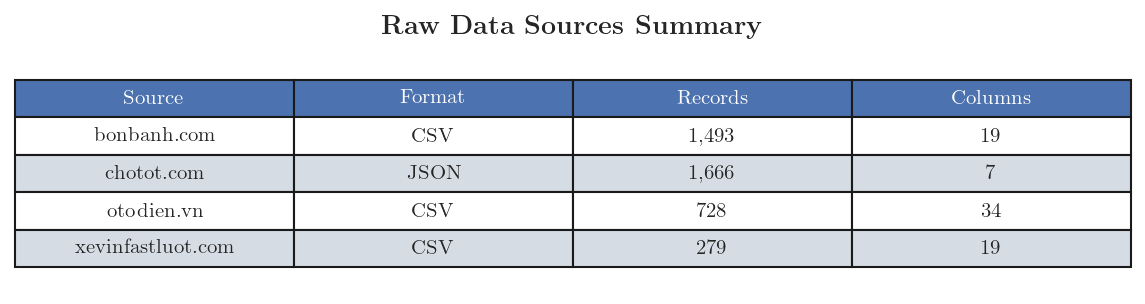

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\data_sources_summary.pdf


In [6]:
# --- Summary table of all sources ---
source_info = []
for name, df, fmt in [
    ("bonbanh.com", df_bb, "CSV"),
    ("chotot.com", df_ct, "JSON"),
    ("otodien.vn", df_od, "CSV"),
    ("xevinfastluot.com", df_vfl, "CSV"),
]:
    source_info.append({
        "Source": name,
        "Format": fmt,
        "Records": f"{len(df):,}",
        "Columns": df.shape[1] if len(df) > 0 else 0,
    })

summary_df = pd.DataFrame(source_info)
display(summary_df)

# Save as PDF table
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis("off")
ax.set_title(r"\textbf{Raw Data Sources Summary}", fontsize=13, pad=12)
tbl = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(TABLE_HEADER)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor(TABLE_ROW_ALT)
fig.savefig(REPORTS / "data_sources_summary.pdf")
plt.show()
print(f"Saved: {REPORTS / 'data_sources_summary.pdf'}")


## 2. Data Merging

The `harmonize\_datasets.py` script maps all 4 heterogeneous schemas into a
unified 20-column format. The core features are:

| \# | Column | Description |
|----|--------|-------------|
| 1 | Post date | Listing date |
| 2 | Car name | Raw title string |
| 3 | Price | Asking price (raw text) |
| 4--17 | Vehicle attrs | Seller, location, year, condition, mileage, etc. |
| 18 | Description | Free-text body |
| 19 | Link | Source URL |
| 20 | Website | Source identifier |

Key mapping challenges:
- **chotot.com**: deeply nested JSON; price in VND integer; attributes inside `ad\_params` dict
- **otodien.vn**: 34 columns including EV-specific specs (battery kWh, range km); no gearbox/engine columns (all-EV platform)
- **bonbanh.com / xevinfastluot.com**: already close to the target schema


In [7]:
# Load the merged dataset
merged_path = DATA_INTERIM / "merged_raw_listings.csv"
try:
    merged = pd.read_csv(merged_path, encoding="utf-8-sig")
    print(f"Merged dataset: {merged.shape[0]:,} records x {merged.shape[1]} columns")
    print(f"\nColumns: {list(merged.columns)}")
    display(merged.head(3))
except Exception as e:
    merged = pd.DataFrame()
    print(f"Failed to load merged: {e}")


Merged dataset: 4,166 records x 20 columns

Columns: ['Ngày đăng', 'Tên xe', 'Giá', 'Tên người bán', 'Địa chỉ', 'Năm sản xuất', 'Tình trạng', 'Số Km đã đi', 'Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Động cơ', 'Màu ngoại thất', 'Màu nội thất', 'Số chỗ ngồi', 'Số cửa', 'Dẫn động', 'Mô tả', 'Link', 'Website']


,Ngày đăng,Tên xe,Giá,Tên người bán,Địa chỉ,Năm sản xuất,Tình trạng,Số Km đã đi,Xuất xứ,Kiểu dáng,Hộp số,Động cơ,Màu ngoại thất,Màu nội thất,Số chỗ ngồi,Số cửa,Dẫn động,Mô tả,Link,Website
0,28/02/2026,Xe\r\n\r\n\t\t\t\t\t\t\tVinFast VF8\r\n\t\t\t\t\t\tPlus AWD\r\n\t\t\t\t\t\t2023,659 Triệu,GF Hoàng Quốc Việt,"14 Hoàng Quốc Việt, Cầu Giấy Hà Nội","2,023.00",Xe đã dùng,"50,000 Km",Lắp ráp trong nước,SUV,Số tự động,Điện,Đen,Đen,5 chỗ,5 cửa,AWD - 4 bánh toàn thời gian,VF8 2022 MÀU ĐEN – XE ĐẸP BẢN PLUS – QUÀ NOEL HẤP DẪN! | Cuối năm săn xe đẹp...,https://bonbanh.com/xe-vinfast-vf8-plus-awd-2023-6592486,bonbanh.com
1,28/02/2026,Xe\r\n\r\n\t\t\t\t\t\t\tVinFast VF8\r\n\t\t\t\t\t\tEco\r\n\t\t\t\t\t\t2026,790 Triệu,Vinfast Times City,"Tầng B1, TTTM Vincom Times City - 458 Minh Khai, Vĩnh Tuy, Hai Bà Trưng Hà Nội","2,026.00",Xe mới,NaN,Lắp ráp trong nước,SUV,Số tự động,Điện,Trắng,Đen,5 chỗ,5 cửa,FWD - Dẫn động cầu trước,Vinfast VF8 (VF E35) 2026 | Xe điện mới 100% | Kích thước tổng thể (DxRxC) (...,https://bonbanh.com/xe-vinfast-vf8-eco-2026-6544996,bonbanh.com
2,28/02/2026,Xe\r\n\r\n\t\t\t\t\t\t\tVinFast VF8\r\n\t\t\t\t\t\tPlus AWD\r\n\t\t\t\t\t\t2023,599 Triệu,GF Hoàng Quốc Việt,"14 Hoàng Quốc Việt, Cầu Giấy Hà Nội","2,023.00",Xe đã dùng,"99,000 Km",Lắp ráp trong nước,SUV,Số tự động,Điện,Xanh,Nhiều màu,5 chỗ,5 cửa,AWD - 4 bánh toàn thời gian,VF8 2023 MÀU Xanh– XE ĐẸP BẢN PLUS – QUÀ NOEL HẤP DẪN! | Cuối năm săn xe đẹp...,https://bonbanh.com/xe-vinfast-vf8-plus-awd-2023-6592500,bonbanh.com


In [8]:
# Column overlap across sources (which fields each source populates)
if len(merged) > 0 and "Website" in merged.columns:
    fill_rates = merged.groupby("Website").apply(
        lambda g: g.notna().mean()
    ).T
    fill_rates = fill_rates.drop("Website", errors="ignore")
    print("Field fill rate by source (proportion non-null):")
    display(fill_rates.round(2))


Field fill rate by source (proportion non-null):


Website,bonbanh.com,chotot.com,otodien.vn,xevinfastluot.com
Ngày đăng,1.00,1.00,1.00,1.00
Tên xe,1.00,1.00,1.00,1.00
Giá,1.00,1.00,1.00,1.00
Tên người bán,1.00,1.00,1.00,1.00
Địa chỉ,1.00,1.00,1.00,1.00
Năm sản xuất,1.00,1.00,0.00,0.98
Tình trạng,1.00,1.00,0.00,1.00
Số Km đã đi,0.58,0.53,0.00,1.00
Xuất xứ,1.00,1.00,0.00,1.00
Kiểu dáng,1.00,0.68,1.00,1.00


Records per source:
Website
chotot.com           1666
bonbanh.com          1493
otodien.vn            728
xevinfastluot.com     279
Name: count, dtype: int64


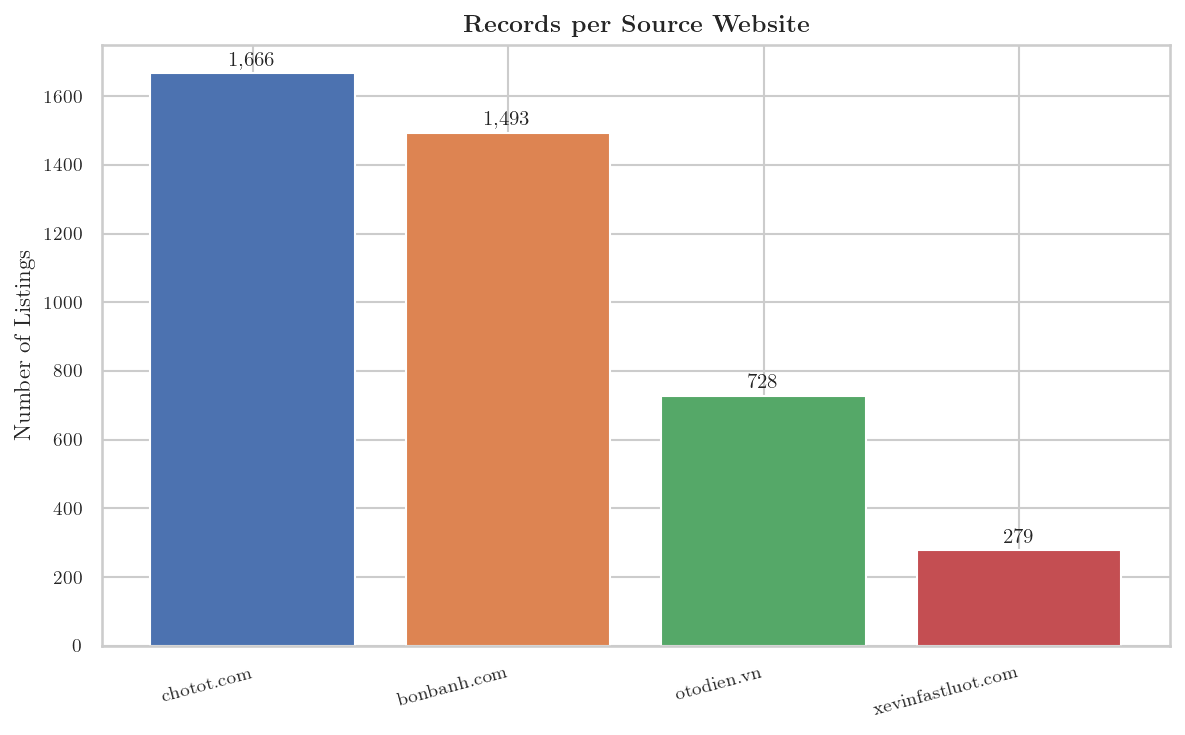

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\records_per_source.pdf


In [9]:
# Records per source
if len(merged) > 0 and "Website" in merged.columns:
    src_counts = merged["Website"].value_counts()
    print("Records per source:")
    print(src_counts)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(range(len(src_counts)), src_counts.values, color=PALETTE[:len(src_counts)])
    ax.set_xticks(range(len(src_counts)))
    ax.set_xticklabels([s.replace("_", r"\_") for s in src_counts.index],
                       rotation=15, ha="right")
    ax.set_ylabel(r"Number of Listings")
    ax.set_title(r"\textbf{Records per Source Website}")
    for bar, val in zip(bars, src_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    fig.tight_layout()
    fig.savefig(REPORTS / "records_per_source.pdf")
    plt.show()
    print(f"Saved: {REPORTS / 'records_per_source.pdf'}")


## 3. LLM Feature Extraction

Unstructured text (car name + description) is processed by two LLM pipelines
to extract structured fields:

1. **Local LLM** --- Ollama `qwen2.5:3b` with synchronous extraction, auto-retry,
   and JSON guardrails
2. **Cloud LLM** --- OpenAI GPT-5-nano via batch API for higher accuracy

Both extract: `brand`, `car\_model`, `imputed\_year`, `imputed\_mileage\_km`,
`imputed\_condition`, `battery\_status`, `is\_accident\_free`, `has\_aftermarket\_mods`.


In [10]:
# --- 3a. Qwen 2.5:3b local extraction ---
qwen_path = DATA_INTERIM / "ev_extracted_qwen2.5_3b.csv"
try:
    if qwen_path.exists():
        df_qwen = pd.read_csv(qwen_path, encoding="utf-8-sig")
        print(f"Qwen 2.5:3b extraction: {df_qwen.shape[0]:,} records x {df_qwen.shape[1]} columns")
        print(f"Columns: {list(df_qwen.columns)}")
        display(df_qwen.head(2))
    else:
        df_qwen = pd.DataFrame()
        print("Qwen extraction file not found")
except Exception as e:
    df_qwen = pd.DataFrame()
    print(f"Failed to load Qwen extraction: {e}")


Qwen 2.5:3b extraction: 696 records x 10 columns
Columns: ['id', 'reasoning', 'brand', 'car_model', 'imputed_year', 'imputed_mileage_km', 'imputed_condition', 'battery_status', 'is_accident_free', 'has_aftermarket_mods']


,id,reasoning,brand,car_model,imputed_year,imputed_mileage_km,imputed_condition,battery_status,is_accident_free,has_aftermarket_mods
0,0,"Màu đen lịch lãm, bản Plus full option, vận hành êm ái, pin khỏe",NaN,NaN,NaN,NaN,Đã qua sử dụng,Mua pin,NaN,True
1,1,"2026, mới 100%",NaN,VF8 Eco,"2,026.00",0.00,Mới 100%,Mua pin,NaN,True


In [11]:
# --- 3b. GPT-5-nano batch extraction ---
gpt_path = DATA_INTERIM / "ev_extracted_gpt5nano.csv"
try:
    if gpt_path.exists():
        df_gpt = pd.read_csv(gpt_path, encoding="utf-8-sig")
        print(f"GPT-5-nano extraction: {df_gpt.shape[0]:,} records x {df_gpt.shape[1]} columns")
        print(f"Columns: {list(df_gpt.columns)}")
        display(df_gpt.head(2))
    else:
        df_gpt = pd.DataFrame()
        print("GPT-5-nano extraction file not found")
except Exception as e:
    df_gpt = pd.DataFrame()
    print(f"Failed to load GPT-5-nano extraction: {e}")


GPT-5-nano extraction: 3,991 records x 10 columns
Columns: ['id', 'reasoning', 'brand', 'car_model', 'imputed_year', 'imputed_mileage_km', 'imputed_condition', 'battery_status', 'is_accident_free', 'has_aftermarket_mods']


,id,reasoning,brand,car_model,imputed_year,imputed_mileage_km,imputed_condition,battery_status,is_accident_free,has_aftermarket_mods
0,0,From Name: 'Xe VinFast VF8 Plus AWD 2023' implies brand VinFast and model VF...,VinFast,VF8 Plus AWD,"2,023.00","50,000.00",NaN,NaN,NaN,False
1,1,From Name: 'Xe VinFast VF8 Eco 2026' implies brand VinFast and model VF8 Eco...,VinFast,VF8 Eco,"2,026.00",0.00,Mới 100%,NaN,NaN,False


In [12]:
# --- 3c. Extraction fill rates ---
extract_cols = ["brand", "car_model", "imputed_year", "imputed_mileage_km",
                "imputed_condition", "battery_status", "is_accident_free",
                "has_aftermarket_mods"]

fill_data = {}
for name, df in [("Qwen 2.5:3b", df_qwen), ("GPT-5-nano", df_gpt)]:
    if len(df) > 0:
        rates = {}
        for col in extract_cols:
            if col in df.columns:
                rates[col] = f"{df[col].notna().mean():.1%}"
            else:
                rates[col] = "N/A"
        fill_data[name] = rates

if fill_data:
    fill_df = pd.DataFrame(fill_data)
    print("Extraction fill rates (proportion non-null):")
    display(fill_df)
else:
    print("No extraction data available to compare.")


Extraction fill rates (proportion non-null):


,Qwen 2.5:3b,GPT-5-nano
brand,84.1%,99.1%
car_model,96.6%,99.6%
imputed_year,89.8%,78.4%
imputed_mileage_km,91.8%,42.9%
imputed_condition,98.1%,23.3%
battery_status,56.2%,25.3%
is_accident_free,21.1%,11.3%
has_aftermarket_mods,100.0%,100.0%


## 4. Rule-Based Cleaning

After LLM extraction, `preprocess\_rule\_based.py` applies deterministic
transformations:

- **Price normalization**: convert text prices to numeric VND
- **Field standardization**: unify condition labels, normalize mileage units
- **ICE vehicle removal**: filter to electric vehicles only
- **Deduplication**: remove exact duplicates by URL


In [13]:
# Load cleaned dataset
cleaned_path = DATA_INTERIM / "ev_cleaned_rule_based.csv"
try:
    df_cleaned = pd.read_csv(cleaned_path, encoding="utf-8-sig")
    print(f"Rule-based cleaned: {df_cleaned.shape[0]:,} records x {df_cleaned.shape[1]} columns")
    print(f"\nColumns: {list(df_cleaned.columns)}")
    display(df_cleaned.head(3))
except Exception as e:
    df_cleaned = pd.DataFrame()
    print(f"Failed to load cleaned data: {e}")


Rule-based cleaned: 3,992 records x 18 columns

Columns: ['Ngày đăng', 'Tên xe', 'Tên người bán', 'Địa chỉ', 'Năm sản xuất', 'Tình trạng', 'Số Km đã đi', 'Xuất xứ', 'Kiểu dáng', 'Màu ngoại thất', 'Màu nội thất', 'Số chỗ ngồi', 'Số cửa', 'Dẫn động', 'Mô tả', 'Link', 'Website', 'Giá_VND']


,Ngày đăng,Tên xe,Tên người bán,Địa chỉ,Năm sản xuất,Tình trạng,Số Km đã đi,Xuất xứ,Kiểu dáng,Màu ngoại thất,Màu nội thất,Số chỗ ngồi,Số cửa,Dẫn động,Mô tả,Link,Website,Giá_VND
0,2026-02-28,Xe VinFast VF8 Plus AWD 2023,GF Hoàng Quốc Việt,"14 Hoàng Quốc Việt, Cầu Giấy Hà Nội","2,023.00",Xe đã dùng,"50,000 Km",Lắp ráp trong nước,SUV,Đen,Đen,5 chỗ,5 cửa,AWD - 4 bánh toàn thời gian,VF8 2022 MÀU ĐEN – XE ĐẸP BẢN PLUS – QUÀ NOEL HẤP DẪN! | Cuối năm săn xe đẹp...,https://bonbanh.com/xe-vinfast-vf8-plus-awd-2023-6592486,bonbanh.com,"659,000,000.00"
1,2026-02-28,Xe VinFast VF8 Eco 2026,Vinfast Times City,"Tầng B1, TTTM Vincom Times City - 458 Minh Khai, Vĩnh Tuy, Hai Bà Trưng Hà Nội","2,026.00",Xe mới,NaN,Lắp ráp trong nước,SUV,Trắng,Đen,5 chỗ,5 cửa,FWD - Dẫn động cầu trước,Vinfast VF8 (VF E35) 2026 | Xe điện mới 100% | Kích thước tổng thể (DxRxC) (...,https://bonbanh.com/xe-vinfast-vf8-eco-2026-6544996,bonbanh.com,"790,000,000.00"
2,2026-02-28,Xe VinFast VF8 Plus AWD 2023,GF Hoàng Quốc Việt,"14 Hoàng Quốc Việt, Cầu Giấy Hà Nội","2,023.00",Xe đã dùng,"99,000 Km",Lắp ráp trong nước,SUV,Xanh,Nhiều màu,5 chỗ,5 cửa,AWD - 4 bánh toàn thời gian,VF8 2023 MÀU Xanh– XE ĐẸP BẢN PLUS – QUÀ NOEL HẤP DẪN! | Cuối năm săn xe đẹp...,https://bonbanh.com/xe-vinfast-vf8-plus-awd-2023-6592500,bonbanh.com,"599,000,000.00"


In [14]:
# Before/after statistics
if len(merged) > 0 and len(df_cleaned) > 0:
    print("=== Before vs After Rule-Based Cleaning ===")
    print(f"  Records:  {merged.shape[0]:,}  ->  {df_cleaned.shape[0]:,}")
    print(f"  Columns:  {merged.shape[1]}  ->  {df_cleaned.shape[1]}")

    # Price comparison if available
    price_col_before = None
    for c in merged.columns:
        if "price" in c.lower() or c == "Gi\u00e1":
            price_col_before = c
            break

    price_col_after = None
    for c in df_cleaned.columns:
        if "price" in c.lower() or "vnd" in c.lower():
            price_col_after = c
            break

    if price_col_after:
        prices = pd.to_numeric(df_cleaned[price_col_after], errors="coerce").dropna()
        if len(prices) > 0:
            print(f"\n  Price stats after cleaning ({price_col_after}):")
            print(f"    Mean:   {prices.mean():,.0f} VND")
            print(f"    Median: {prices.median():,.0f} VND")
            print(f"    Min:    {prices.min():,.0f} VND")
            print(f"    Max:    {prices.max():,.0f} VND")

    # Null rate comparison
    null_before = merged.isnull().mean().mean()
    null_after = df_cleaned.isnull().mean().mean()
    print(f"\n  Avg null rate: {null_before:.1%}  ->  {null_after:.1%}")


=== Before vs After Rule-Based Cleaning ===
  Records:  4,166  ->  3,992
  Columns:  20  ->  18

  Price stats after cleaning (Giá_VND):
    Mean:   2,789,441,383 VND
    Median: 910,000,000 VND
    Min:    9,680,000 VND
    Max:    72,900,000,000 VND

  Avg null rate: 15.2%  ->  17.4%


## 5. EDA-Ready Dataset

The final analysis-ready dataset merges LLM-extracted features with rule-based
cleaned data. This is the input for all modelling work.


In [15]:
# Load EDA-ready dataset
eda_path = DATA_INTERIM / "ev_eda_ready.csv"
try:
    eda = pd.read_csv(eda_path, encoding="utf-8-sig")
    print(f"EDA-ready dataset: {eda.shape[0]:,} records x {eda.shape[1]} columns")
    print(f"\nColumns: {list(eda.columns)}")
    print(f"\nData types:")
    print(eda.dtypes)
    display(eda.head(3))
except Exception as e:
    eda = pd.DataFrame()
    print(f"Failed to load EDA data: {e}")


EDA-ready dataset: 3,974 records x 19 columns

Columns: ['id', 'brand', 'base_model', 'model_mode', 'year', 'condition', 'mileage_km', 'has_aftermarket_mods', 'body_type', 'seats', 'doors', 'drivetrain', 'origin', 'exterior_color', 'city', 'seller_name', 'post_date', 'website', 'price_vnd']

Data types:
id                        int64
brand                       str
base_model                  str
model_mode                  str
year                    float64
condition                   str
mileage_km              float64
has_aftermarket_mods       bool
body_type                   str
seats                   float64
doors                   float64
drivetrain                  str
origin                      str
exterior_color              str
city                        str
seller_name                 str
post_date                   str
website                     str
price_vnd               float64
dtype: object


,id,brand,base_model,model_mode,year,condition,mileage_km,has_aftermarket_mods,body_type,seats,doors,drivetrain,origin,exterior_color,city,seller_name,post_date,website,price_vnd
0,0,VinFast,VF8,VF8 Plus AWD,"2,023.00",Used,"50,000.00",False,SUV,5.00,5.00,AWD - 4 bánh toàn thời gian,Lắp ráp trong nước,Đen,Hà Nội,GF Hoàng Quốc Việt,2026-02-28,bonbanh.com,"659,000,000.00"
1,1,VinFast,VF8,VF8 Eco,"2,026.00",New,0.00,False,SUV,5.00,5.00,FWD - Dẫn động cầu trước,Lắp ráp trong nước,Trắng,Hà Nội,Vinfast Times City,2026-02-28,bonbanh.com,"790,000,000.00"
2,2,VinFast,VF8,VF8 Plus AWD,"2,023.00",Used,"99,000.00",False,SUV,5.00,5.00,AWD - 4 bánh toàn thời gian,Lắp ráp trong nước,Xanh,Hà Nội,GF Hoàng Quốc Việt,2026-02-28,bonbanh.com,"599,000,000.00"


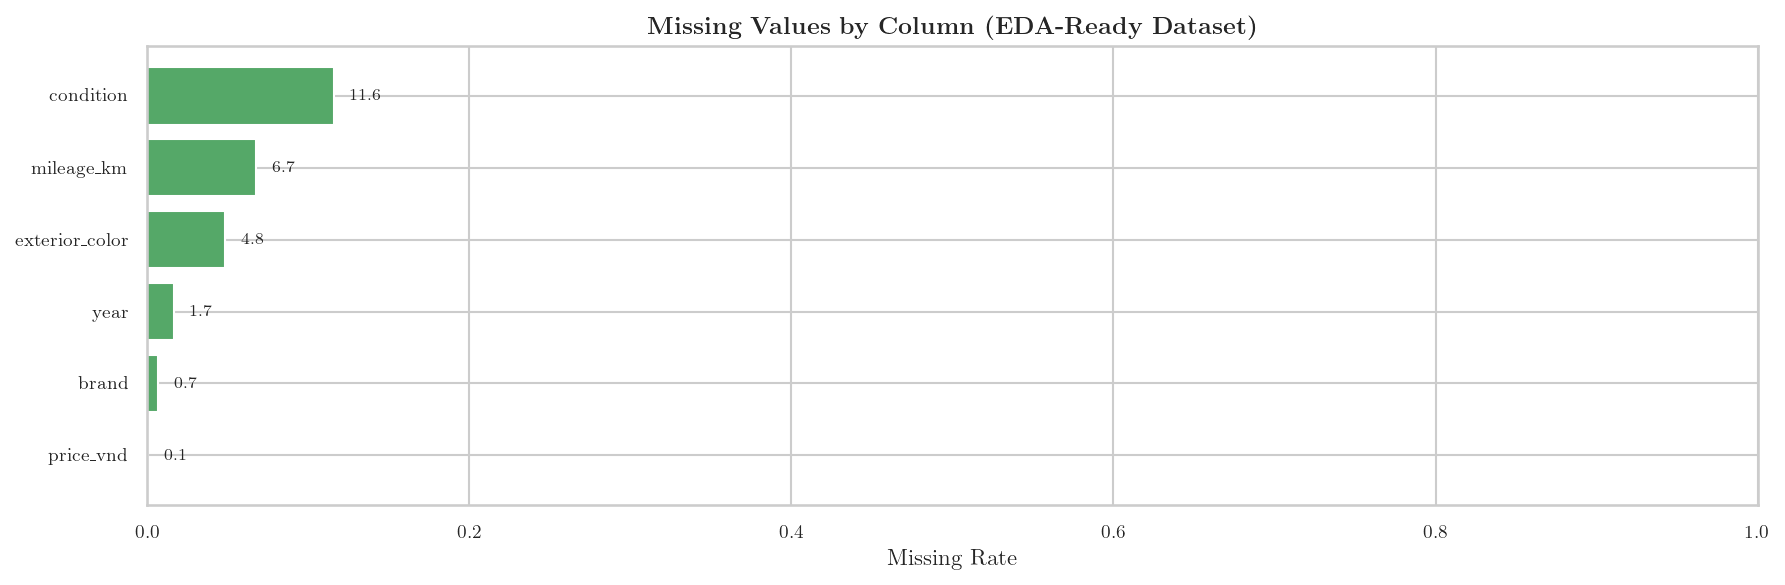

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\missing_values_heatmap.pdf


In [16]:
# Missing values heatmap
if len(eda) > 0:
    null_pct = eda.isnull().mean().sort_values(ascending=False)
    cols_with_nulls = null_pct[null_pct > 0]

    if len(cols_with_nulls) > 0:
        fig, ax = plt.subplots(figsize=(12, max(4, len(cols_with_nulls) * 0.35)))
        colors = [COLOR_BAD if v > 0.5 else COLOR_ACCENT if v > 0.2 else COLOR_GOOD
                  for v in cols_with_nulls.values]
        bars = ax.barh(range(len(cols_with_nulls)), cols_with_nulls.values, color=colors)
        ax.set_yticks(range(len(cols_with_nulls)))
        ax.set_yticklabels([c.replace("_", r"\_") for c in cols_with_nulls.index], fontsize=9)
        ax.set_xlabel(r"Missing Rate")
        ax.set_title(r"\textbf{Missing Values by Column (EDA-Ready Dataset)}")
        ax.set_xlim(0, 1)
        for bar, val in zip(bars, cols_with_nulls.values):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{val:.1%}", va="center", fontsize=8)
        ax.invert_yaxis()
        fig.tight_layout()
        fig.savefig(REPORTS / "missing_values_heatmap.pdf")
        plt.show()
        print(f"Saved: {REPORTS / 'missing_values_heatmap.pdf'}")
    else:
        print("No missing values in the EDA-ready dataset!")


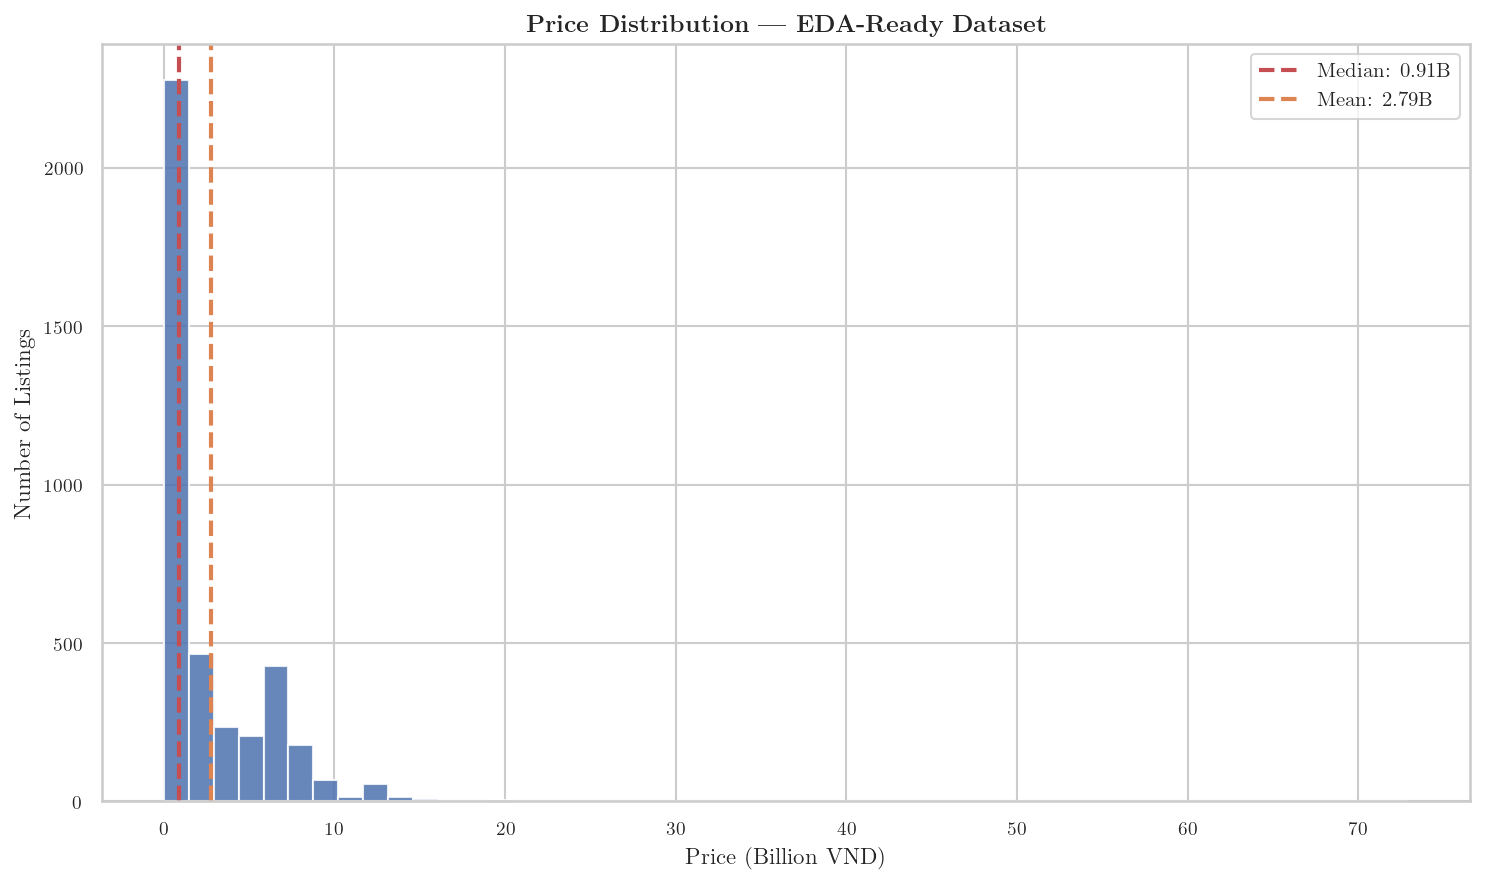

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\price_distribution_raw.pdf


In [17]:
# Price distribution histogram
if len(eda) > 0:
    price_col = None
    for c in eda.columns:
        if "price" in c.lower():
            price_col = c
            break

    if price_col:
        prices = pd.to_numeric(eda[price_col], errors="coerce").dropna()
        prices_bil = prices / 1e9  # Convert to billions VND

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(prices_bil, bins=50, color=COLOR_PRIMARY, edgecolor="white", alpha=0.85)
        ax.set_xlabel(r"Price (Billion VND)")
        ax.set_ylabel(r"Number of Listings")
        ax.set_title(r"\textbf{Price Distribution --- EDA-Ready Dataset}")
        ax.axvline(prices_bil.median(), color=COLOR_BAD, linestyle="--", linewidth=2,
                   label=f"Median: {prices_bil.median():.2f}B")
        ax.axvline(prices_bil.mean(), color=COLOR_ACCENT, linestyle="--", linewidth=2,
                   label=f"Mean: {prices_bil.mean():.2f}B")
        ax.legend(fontsize=10)
        fig.tight_layout()
        fig.savefig(REPORTS / "price_distribution_raw.pdf")
        plt.show()
        print(f"Saved: {REPORTS / 'price_distribution_raw.pdf'}")
    else:
        print("No price column found in EDA-ready dataset")


## 6. Data Quality Discovery --- chotot.com 10x Price Inflation

**Key Finding:** chotot.com listings have systematically inflated prices,
roughly 10x higher than equivalent listings on other platforms.

**Root Cause:** The chotot.com API returns prices in raw VND (e.g.
`882000000` for 882M VND), whereas other sources use text like ``882 Trieu''.
During LLM extraction, the raw integer was sometimes misinterpreted or the
unit mismatch was not corrected, leading to 10x inflation in the merged data.


Median Price by Model and Website (Million VND):


website,bonbanh.com,chotot.com,otodien.vn,xevinfastluot.com
base_model,,,,
VF3,250.00,"2,550.00",271.00,252.00
VF5,438.00,"4,360.00",480.00,440.00
VF6,639.00,"6,330.00",661.00,615.00
VF8,730.00,"7,750.00",790.00,770.00
VF9,"1,262.00","12,290.00","1,190.00","1,180.00"


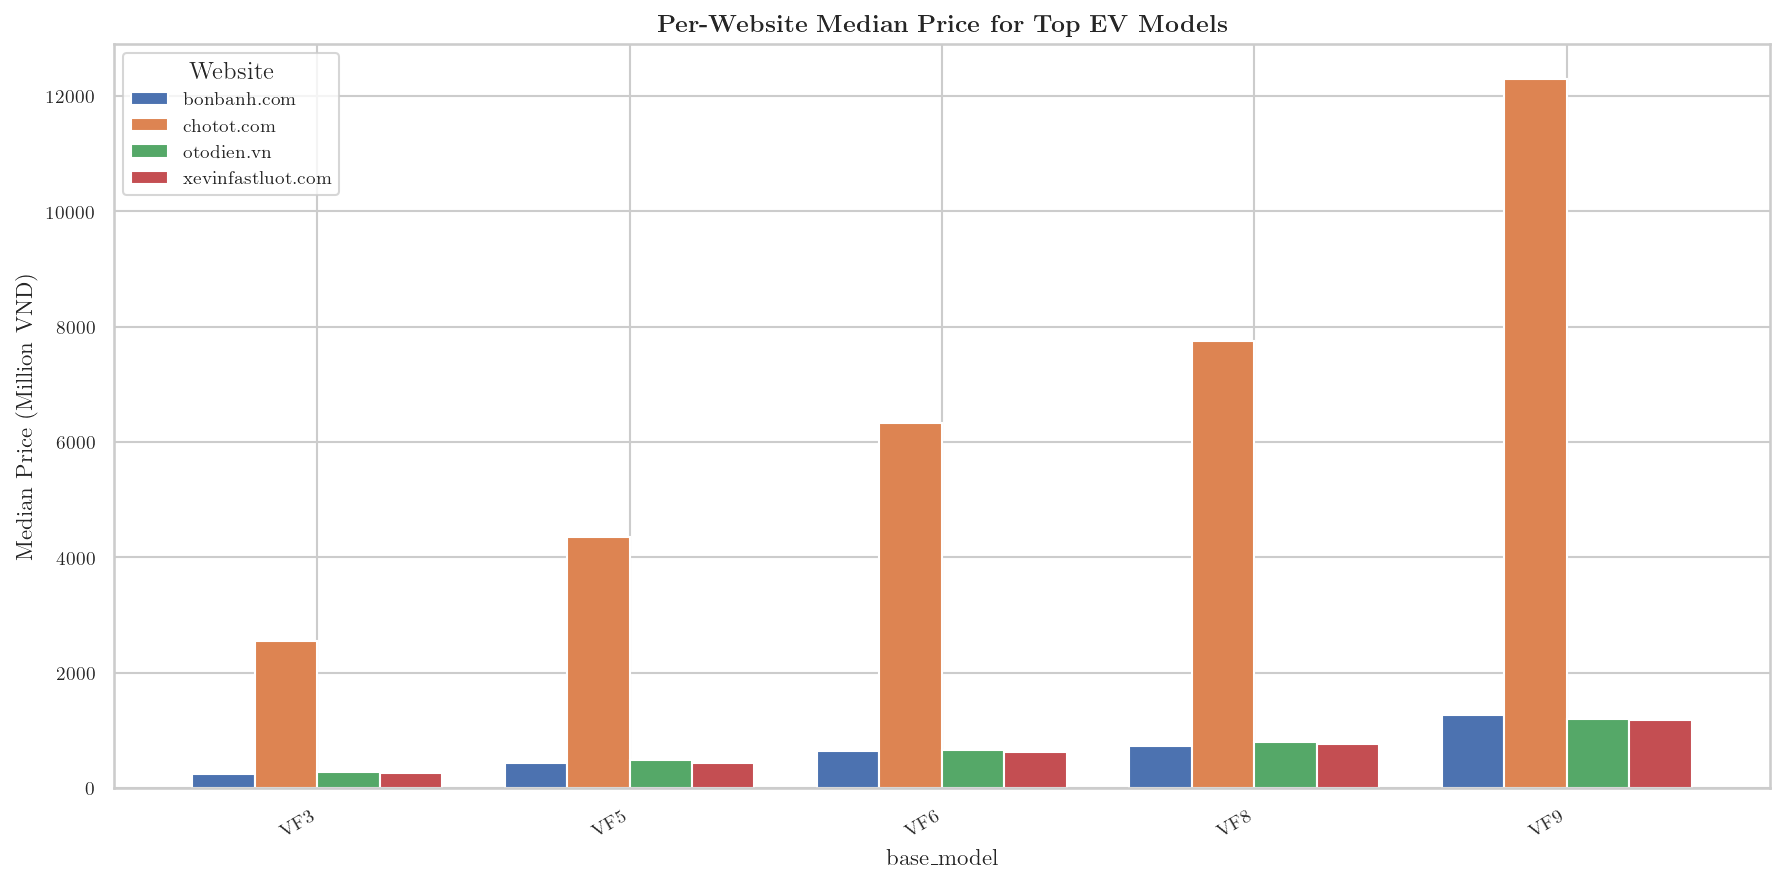

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\website_price_comparison.pdf


In [18]:
# Per-website median price for top VinFast models
if len(eda) > 0 and "website" in eda.columns:
    price_col = None
    for c in eda.columns:
        if "price" in c.lower():
            price_col = c
            break

    model_col = None
    for c in eda.columns:
        if "model" in c.lower() and "base" in c.lower():
            model_col = c
            break
    if model_col is None:
        for c in eda.columns:
            if "model" in c.lower():
                model_col = c
                break

    if price_col and model_col:
        prices_numeric = pd.to_numeric(eda[price_col], errors="coerce")
        eda_priced = eda.assign(_price=prices_numeric).dropna(subset=["_price"])

        # Top models by frequency
        top_models = eda_priced[model_col].value_counts().head(5).index.tolist()
        subset = eda_priced[eda_priced[model_col].isin(top_models)]

        if len(subset) > 0:
            pivot = subset.pivot_table(
                values="_price",
                index=model_col,
                columns="website",
                aggfunc="median"
            ) / 1e6  # millions VND

            print("Median Price by Model and Website (Million VND):")
            display(pivot.round(0))

            # Bar chart comparison
            fig, ax = plt.subplots(figsize=(12, 6))
            pivot.plot(kind="bar", ax=ax, width=0.8)
            ax.set_ylabel(r"Median Price (Million VND)")
            ax.set_title(r"\textbf{Per-Website Median Price for Top EV Models}")
            ax.set_xticklabels([str(m).replace("_", r"\_") for m in pivot.index],
                               rotation=30, ha="right")
            ax.legend(title=r"Website", fontsize=9)
            fig.tight_layout()
            fig.savefig(REPORTS / "website_price_comparison.pdf")
            plt.show()
            print(f"Saved: {REPORTS / 'website_price_comparison.pdf'}")
    else:
        print("Required columns not found for website price comparison")
elif len(eda) > 0:
    print("No 'website' column in EDA-ready dataset; skipping per-website analysis.")


## 7. Data Quality Discovery --- BYD Price Anomaly

**Key Finding:** All BYD records have systematically incorrect (inflated)
prices. This is likely caused by scraping or extraction errors specific to
BYD listing formats on Vietnamese platforms.


BYD records:     90
Non-BYD records: 3,882

BYD median price:     6,595,000,000 VND
Non-BYD median price: 892,500,000 VND
Ratio (BYD / non-BYD): 7.4x


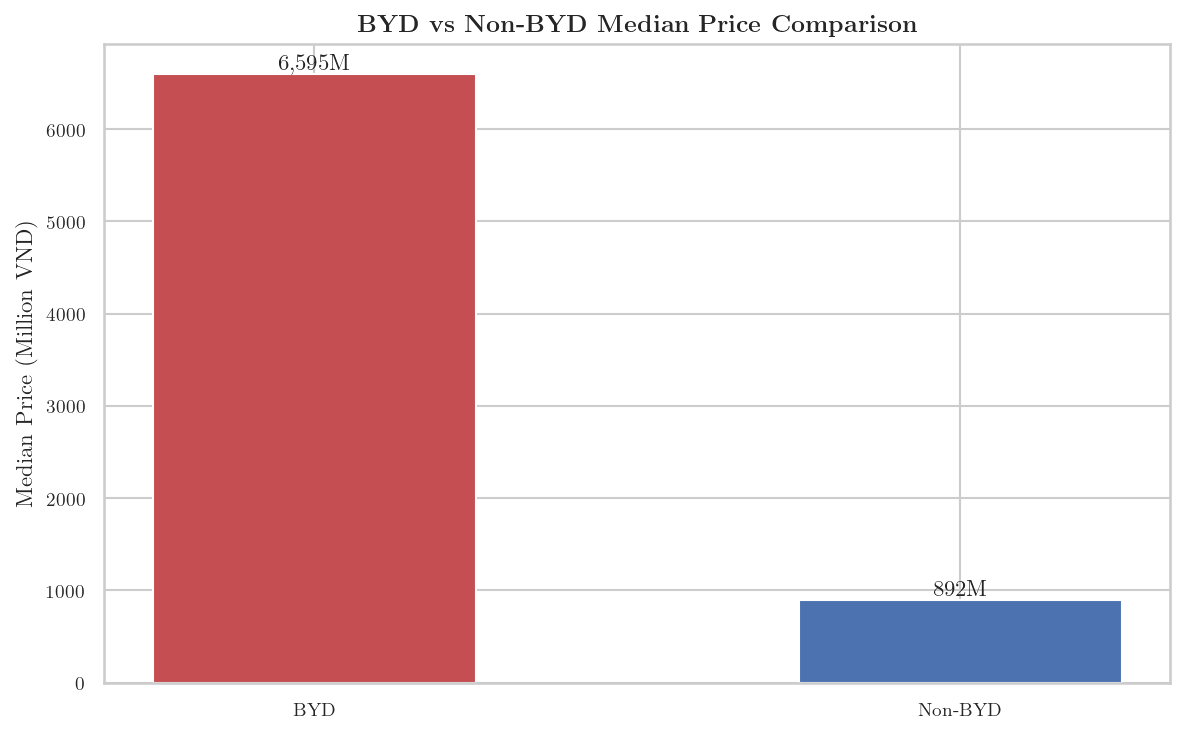

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\byd_price_anomaly.pdf


In [19]:
# BYD vs non-BYD price comparison
if len(eda) > 0:
    brand_col = None
    for c in eda.columns:
        if "brand" in c.lower():
            brand_col = c
            break

    price_col = None
    for c in eda.columns:
        if "price" in c.lower():
            price_col = c
            break

    if brand_col and price_col:
        eda_priced = eda.copy()
        eda_priced["_price"] = pd.to_numeric(eda_priced[price_col], errors="coerce")
        eda_priced = eda_priced.dropna(subset=["_price"])

        byd_mask = eda_priced[brand_col].str.contains("BYD", case=False, na=False)
        byd_prices = eda_priced.loc[byd_mask, "_price"]
        non_byd_prices = eda_priced.loc[~byd_mask, "_price"]

        print(f"BYD records:     {byd_mask.sum():,}")
        print(f"Non-BYD records: {(~byd_mask).sum():,}")

        if len(byd_prices) > 0:
            print(f"\nBYD median price:     {byd_prices.median():,.0f} VND")
            print(f"Non-BYD median price: {non_byd_prices.median():,.0f} VND")
            print(f"Ratio (BYD / non-BYD): {byd_prices.median() / non_byd_prices.median():.1f}x")

            # Bar chart
            fig, ax = plt.subplots(figsize=(8, 5))
            categories = [r"BYD", r"Non-BYD"]
            medians = [byd_prices.median() / 1e6, non_byd_prices.median() / 1e6]
            bars = ax.bar(categories, medians, color=[COLOR_BAD, COLOR_PRIMARY], width=0.5)
            ax.set_ylabel(r"Median Price (Million VND)")
            ax.set_title(r"\textbf{BYD vs Non-BYD Median Price Comparison}")
            for bar, val in zip(bars, medians):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        f"{val:,.0f}M", ha="center", va="bottom", fontsize=11)
            fig.tight_layout()
            fig.savefig(REPORTS / "byd_price_anomaly.pdf")
            plt.show()
            print(f"Saved: {REPORTS / 'byd_price_anomaly.pdf'}")
        else:
            print("No BYD records found in dataset.")
    else:
        print("Required columns not found for BYD analysis.")


## 8. Duplicate Analysis

Cross-platform listings and re-posts create duplicate entries. We define
duplicates as records sharing the same `(brand, model, year, price)` tuple.


Duplicate key columns: ['brand', 'base_model', 'year', 'price_vnd']
Total unique groups: 1,839
Groups with duplicates (>1): 705
Total duplicate records: 2,041

Duplicate group size distribution:
count   705.00
mean      3.90
std       3.08
min       2.00
25%       2.00
50%       3.00
75%       4.00
max      27.00
dtype: float64


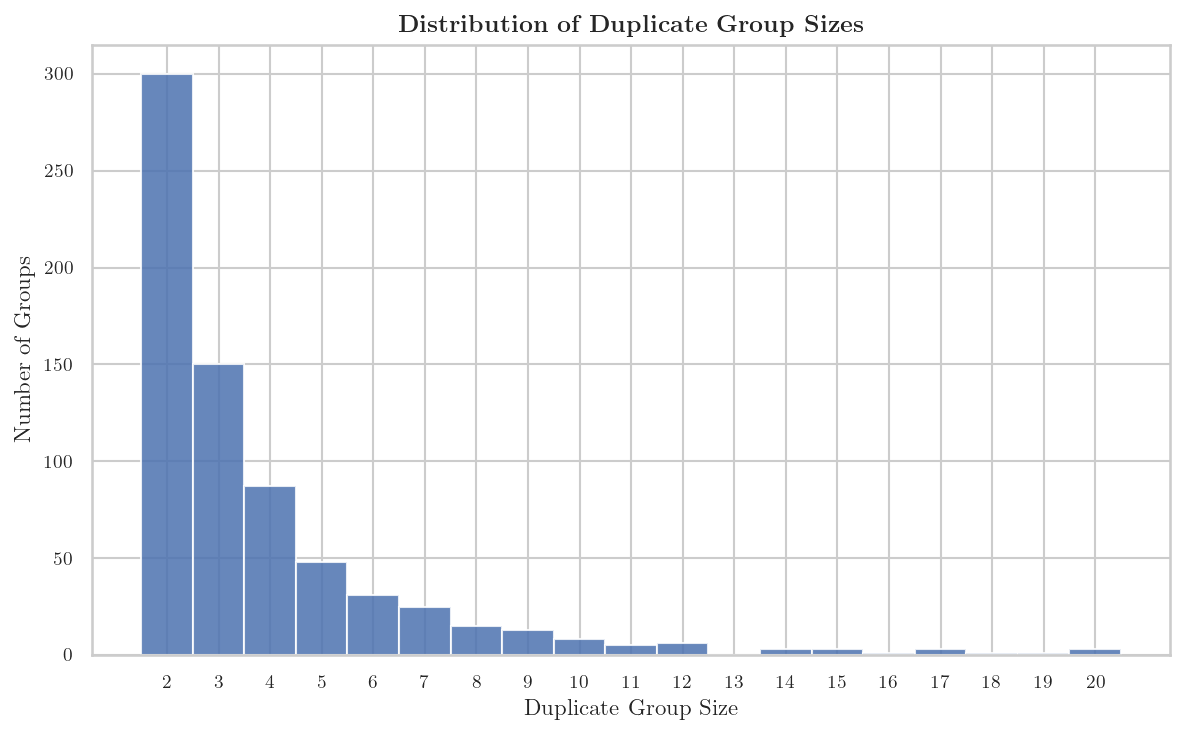

Saved: C:\Users\dduya\Work\project\ev_car\reports\prep_eda\duplicate_analysis.pdf


In [20]:
# Duplicate analysis
if len(eda) > 0:
    # Identify relevant columns
    brand_col = None
    model_col = None
    year_col = None
    price_col = None

    for c in eda.columns:
        cl = c.lower()
        if "brand" in cl and brand_col is None:
            brand_col = c
        if "model" in cl and "base" in cl and model_col is None:
            model_col = c
        if "year" in cl and year_col is None:
            year_col = c
        if "price" in cl and price_col is None:
            price_col = c

    if model_col is None:
        for c in eda.columns:
            if "model" in c.lower():
                model_col = c
                break

    dup_cols = [c for c in [brand_col, model_col, year_col, price_col] if c is not None]

    if len(dup_cols) >= 3:
        eda_clean = eda.dropna(subset=dup_cols)
        dup_groups = eda_clean.groupby(dup_cols).size()
        dup_groups_gt1 = dup_groups[dup_groups > 1]

        print(f"Duplicate key columns: {dup_cols}")
        print(f"Total unique groups: {len(dup_groups):,}")
        print(f"Groups with duplicates (>1): {len(dup_groups_gt1):,}")
        print(f"Total duplicate records: {dup_groups_gt1.sum() - len(dup_groups_gt1):,}")

        if len(dup_groups_gt1) > 0:
            print(f"\nDuplicate group size distribution:")
            print(dup_groups_gt1.describe())

            # Histogram of group sizes
            fig, ax = plt.subplots(figsize=(8, 5))
            max_size = min(int(dup_groups_gt1.max()), 20)
            ax.hist(dup_groups_gt1.values, bins=range(2, max_size + 2),
                    color=COLOR_PRIMARY, edgecolor="white", alpha=0.85, align="left")
            ax.set_xlabel(r"Duplicate Group Size")
            ax.set_ylabel(r"Number of Groups")
            ax.set_title(r"\textbf{Distribution of Duplicate Group Sizes}")
            ax.set_xticks(range(2, max_size + 1))
            fig.tight_layout()
            fig.savefig(REPORTS / "duplicate_analysis.pdf")
            plt.show()
            print(f"Saved: {REPORTS / 'duplicate_analysis.pdf'}")
        else:
            print("No duplicate groups found!")
    else:
        print(f"Not enough key columns found for dedup analysis. Found: {dup_cols}")


## 9. Pipeline Summary

Data flows through the following stages:

```
4 Raw Sources  -->  Merge (harmonize)  -->  LLM Extraction  -->  Rule Cleaning  -->  EDA-Ready
```

Each stage filters, transforms, and enriches the data.


In [21]:
# Pipeline summary with record counts
stages = []

# Raw sources
raw_total = len(df_bb) + len(df_ct) + len(df_od) + len(df_vfl)
stages.append(("1. Raw sources (4 websites)", raw_total))

# Merged
if len(merged) > 0:
    stages.append(("2. After merging", len(merged)))

# LLM extraction
llm_count = max(len(df_qwen), len(df_gpt))
if llm_count > 0:
    stages.append(("3. After LLM extraction", llm_count))

# Rule-based cleaning
if len(df_cleaned) > 0:
    stages.append(("4. After rule-based cleaning", len(df_cleaned)))

# EDA-ready
if len(eda) > 0:
    stages.append(("5. EDA-ready dataset", len(eda)))

print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
for stage_name, count in stages:
    print(f"  {stage_name:<40s} {count:>6,} records")
print("=" * 60)

if len(stages) >= 2:
    total_raw = stages[0][1]
    total_final = stages[-1][1]
    if total_raw > 0:
        print(f"\n  Retention rate: {total_final/total_raw:.1%}")
        print(f"  Records dropped: {total_raw - total_final:,}")


PIPELINE SUMMARY
  1. Raw sources (4 websites)               4,166 records
  2. After merging                          4,166 records
  3. After LLM extraction                   3,991 records
  4. After rule-based cleaning              3,992 records
  5. EDA-ready dataset                      3,974 records

  Retention rate: 95.4%
  Records dropped: 192
